In [1]:
# Importing All Necessary Libraries
import pandas as pd
import numpy as np
import random
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

c:\Users\Tatha\anaconda3\envs\twitter-sentiment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

In [3]:
# Setting Random Seeds for Reproducible same robust results

seed_value = 50
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)

In [4]:
df = pd.read_csv('D:/CODING/projects GitHub/tweet_sentiment_analysis/dataset/CDAC_twitter_labelled/manually_labelled_tweets.csv')
print(f"Successfully loaded manually corrected dataset with {len(df)} tweets.")

Successfully loaded manually corrected dataset with 1965 tweets.


In [5]:
df.head()

,textID,text,selected_text,classification
0,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,0
1,088c60f138,my boss is bullying me...,bullying me,0
2,9642c003ef,what interview! leave me alone,leave me alone,0
3,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",0
4,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,1


In [6]:
df = df.dropna()
print(f"Rows after removing nulls: {len(df)}")  # Use original text if cleaned_text is null

Rows after removing nulls: 1964


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 1964 entries, 0 to 1964
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   textID          1964 non-null   str  
 1   text            1964 non-null   str  
 2   selected_text   1964 non-null   str  
 3   classification  1964 non-null   int64
dtypes: int64(1), str(3)
memory usage: 297.2 KB


In [8]:
df['text'] = df['text'].astype(str)

In [9]:
# Preprocessing the text data

def preprocess_text(text):
    text = str(text)  # Converts the input to a string in case it is not already one
    text = re.sub(r'http\S+|www\S+', ' ', text)  # Removes URLs starting with http, https, or www
    text = re.sub(r'@\w+', ' @user ', text)  # Replaces @mentions with a generic placeholder token
    text = re.sub(r'#(\w+)', r'\1', text)  # Removes the # symbol but keeps the hashtag word itself
    text = re.sub(r'\s+', ' ', text).strip()  # Collapses multiple spaces into one and trims leading/trailing spaces
    return text
df['cleaned_text'] = df['text'].apply(preprocess_text)
print("Preprocessing complete.")

Preprocessing complete.


In [10]:
# Preparing data for the model for training
texts = df['cleaned_text'].tolist() #sepearting texts
labels = df['classification'].tolist() #seperating the classification data

# splitting the data into a training set and a testing set.
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
print("Data has been split.")

Data has been split.


In [11]:
#This guarantees labels are numeric integers before dataset creation and training.
train_labels = [int(x) for x in train_labels]
test_labels = [int(x) for x in test_labels]

In [12]:
# Tokenization and padding
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

# here the Hugging Face tokenizer is tokenizing, truncating and padding
# USING TOO MUCH RAM Hence the below change
"""train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=64)
print("Tokenization and padding of data complete.")"""

# Regulate max_length of tweets tokenization to reduce RAM usage
max_length = 128

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [ ]:
#This tokenizes each sample only when needed during training, instead of storing all tokenized rows in RAM.
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(label, dtype=torch.long)
        return item


train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, max_length=max_length)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, max_length=max_length)

#can tweak batch_size for RAM usage moderation
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Created PyTorch datasets and dataloaders successfully.")

Created PyTorch datasets and dataloaders successfully.


In [14]:
# Loading the Pre-Trained Transformer model DistilBERT
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

print("Pre-trained DistilBERT PyTorch model loaded successfully.")
print(f"Using device: {device}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pre-trained DistilBERT PyTorch model loaded successfully.
Using device: cpu


In [ ]:
# Training the model

# using EarlyStopping to prevent overfitting.
from tqdm.auto import tqdm
from copy import deepcopy

num_epochs = 10
patience = 1
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    train_correct = 0
    train_total = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    for step, batch in enumerate(progress_bar, start=1):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)
        train_correct += (preds == batch['labels']).sum().item()
        train_total += batch['labels'].size(0)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        avg_loss = total_train_loss / step

        progress_bar.set_postfix(train_loss=f"{avg_loss:.4f}")

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0

    val_bar = tqdm(test_loader, desc=f"Validating {epoch+1}/{num_epochs}", leave=False)
    with torch.no_grad():
        for batch in val_bar:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            loss = outputs.loss
            logits = outputs.logits

            total_val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == batch['labels']).sum().item()
            total += batch['labels'].size(0)

    train_accuracy = train_correct / train_total
    avg_val_loss = total_val_loss / len(test_loader)
    val_accuracy = correct / total

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_accuracy'].append(val_accuracy)
    history['train_accuracy'].append(train_accuracy)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter > patience:
            print("Early stopping triggered.")
            break
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("\nModel fine-tuning complete.")

Epoch 1/10:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 99/99 [16:21<00:00,  9.92s/it, train_loss=0.5765]


Epoch 1/10 | Train Loss: 0.5765 | Val Loss: 0.3362 | Val Accuracy: 0.8702Train Accuracy: 0.6665


Epoch 2/10: 100%|██████████| 99/99 [15:03<00:00,  9.13s/it, train_loss=0.3060]


Epoch 2/10 | Train Loss: 0.3060 | Val Loss: 0.2750 | Val Accuracy: 0.9084Train Accuracy: 0.8829


Epoch 3/10: 100%|██████████| 99/99 [17:20<00:00, 10.51s/it, train_loss=0.1392]


Epoch 3/10 | Train Loss: 0.1392 | Val Loss: 0.3335 | Val Accuracy: 0.8855Train Accuracy: 0.9523


Epoch 4/10: 100%|██████████| 99/99 [16:58<00:00, 10.29s/it, train_loss=0.0622]


Epoch 4/10 | Train Loss: 0.0622 | Val Loss: 0.3751 | Val Accuracy: 0.8880Train Accuracy: 0.9809
Early stopping triggered.

Model fine-tuning complete.


Final Test Loss: 0.2750
Final Test Accuracy: 90.84%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.91      0.91       202
    Positive       0.90      0.91      0.91       191

    accuracy                           0.91       393
   macro avg       0.91      0.91      0.91       393
weighted avg       0.91      0.91      0.91       393


Confusion Matrix:


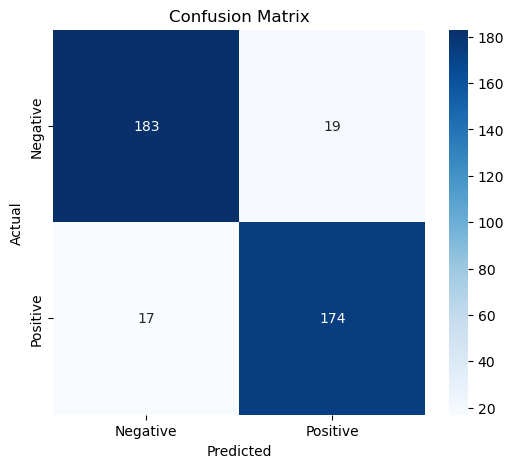

In [16]:
model.eval()
all_preds = []
all_labels = []
total_test_loss = 0

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)

        total_test_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

avg_test_loss = total_test_loss / len(test_loader)
test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))

print(f"Final Test Loss: {avg_test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Visualizing Training History...


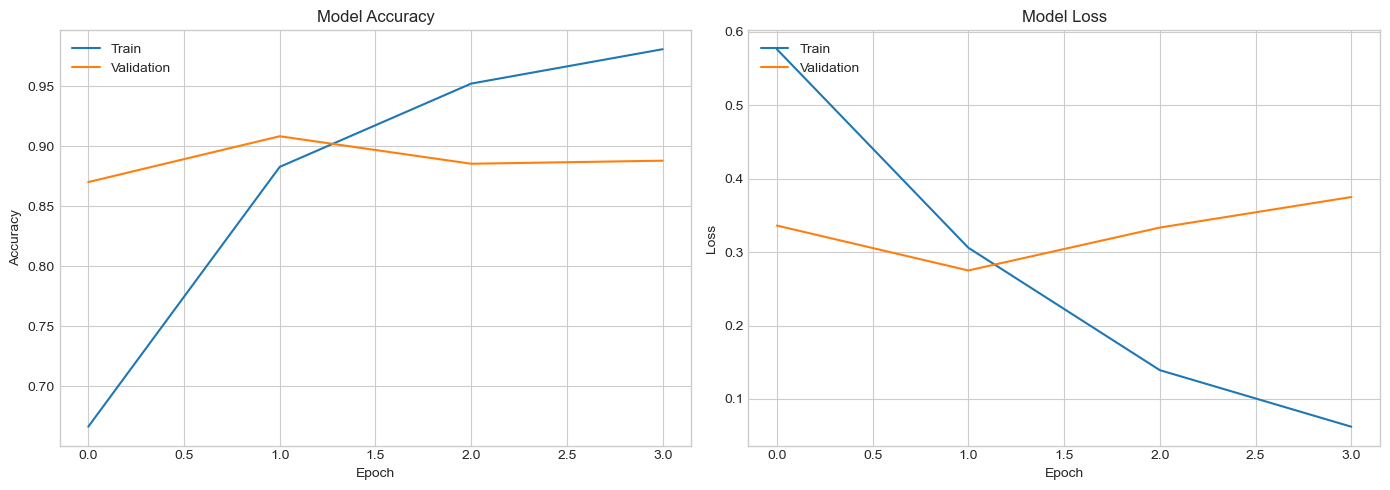

In [17]:
# Visualizing the learning process (train and test curves)

print("\nVisualizing Training History...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_accuracy'])
ax1.plot(history['val_accuracy'])
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')

ax2.plot(history['train_loss'])
ax2.plot(history['val_loss'])
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
# Creating a Prediction function for new inputs

def predict_sentiment_transformer(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding='max_length', max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        predicted_class_id = int(torch.argmax(outputs.logits, dim=-1)[0].cpu().item())

    return "Positive" if predicted_class_id == 1 else "Negative"

In [19]:
# Prediction user interface (CLI)
while True:
    user_input = input("Enter a sentence to analyze, or type 'quit' to exit:")
    if user_input.lower() == 'quit':
        break
    #calling the prediction function
    sentiment = predict_sentiment_transformer(user_input)
    print(f"Predicted Sentiment: {sentiment}")

Predicted Sentiment: Positive
Predicted Sentiment: Negative
Predicted Sentiment: Negative
Predicted Sentiment: Positive


In [20]:
import os
import json

save_dir = "model_artifacts"
os.makedirs(save_dir, exist_ok=True)

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

label_map = {
    "0": "Negative",
    "1": "Positive"
}

with open(os.path.join(save_dir, "label_map.json"), "w") as f:
    json.dump(label_map, f)